# `products_with_language` — EDA & NLP Data Preparation

**Table:** `products_with_language1` in `openfoodfacts.duckdb`  
**Full table size:** 1,206,996 rows × 26 columns  
**Sample used:** 5,300 rows — 500 per top-10 language + 300 NULL-lang rows

---
1. **EDA** — shape, nulls, field coverage, distributions
2. **Text length analysis** — NLP-relevant fields
3. **Language analysis** — distribution & cross-field consistency
4. **Tag field analysis** — structure of tag columns
5. **NLP prep** — cleaning + `nlp_text` construction
6. **Export**

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
pd.set_option('display.max_colwidth', 120)

# Load the stratified sample (500 rows × top-10 langs + 300 NULL-lang)
df = pd.read_csv('products_sample.csv', low_memory=False)
print(f'Sample shape: {df.shape}')
df.head(3)

Sample shape: (5300, 26)


,code,product_name,generic_name,packaging_tags,brands_tags,categories_tags,origins_tags,manufacturing_places_tags,labels_tags,emb_codes_tags,...,food_groups_tags,states_tags,nutrient_levels_tags,data_quality_errors_tags,popularity_tags,nutrition-score-fr_100g,ingredients_text,created_datetime,lang_product_name,lang_ingredients_text
0,13,Powdered peanut butter,NaN,pot-plastique,xx:pbfit,"en:snacks,en:meals,en:rice-dishes,en:risottos,en:powder-peanut-butter",NaN,NaN,NaN,"emb-41106c,fr-41-108-001-ec",...,"en:composite-foods,en:one-dish-meals","en:to-be-completed,en:nutrition-facts-completed,en:ingredients-completed,en:expiration-date-completed,en:packaging-c...","en:fat-in-moderate-quantity,en:saturated-fat-in-high-quantity,en:sugars-in-low-quantity,en:salt-in-low-quantity",en:energy-value-in-kcal-does-not-match-value-computed-from-other-nutrients,"top-90-percent-scans-2019,top-95-percent-scans-2019,top-50000-be-scans-2019,top-100000-be-scans-2019,top-country-be-...",3.0,"Water, Leptospermum Scoparium Mel (Manuka Honey), Sodium C14-C16 Olefin Sulfonate, Cocamide DIPA , Cocamidopropyl B...",2019-03-30 19:25:19+01:00,en,en
1,17,Collagen For Her,NaN,NaN,xx:bodylab,NaN,NaN,NaN,NaN,NaN,...,NaN,"en:to-be-completed,en:nutrition-facts-completed,en:ingredients-completed,en:expiration-date-to-be-completed,en:packa...",NaN,NaN,"top-100000-scans-2024,at-least-5-scans-2024,top-75-percent-scans-2024,top-80-percent-scans-2024,top-85-percent-scans...",NaN,"whey protein concentrate, milk protein concentrate, flavoring, thickener (xanthan gum), sweetener (sucralose)",2024-10-12 14:40:11+02:00,en,en
2,25,Frog Fuel Power Protein,NaN,NaN,xx:frog-fuel,en:protein,NaN,NaN,"en:no-preservatives,en:no-colorings,fr:triman",NaN,...,NaN,"en:to-be-completed,en:nutrition-facts-completed,en:ingredients-completed,en:expiration-date-to-be-completed,en:packa...",NaN,NaN,"top-75-percent-scans-2024,top-80-percent-scans-2024,top-85-percent-scans-2024,top-90-percent-scans-2024,top-50000-ma...",NaN,"glucose syrup, sugar, water, pectin, black carrot concentrate and chlorophyll (color), citric acid, trisodium citrat...",2023-01-10 07:23:08+01:00,en,en


## 1. Field Coverage & Nulls

In [3]:
coverage = pd.DataFrame({
    'non_null': df.notna().sum(),
    'null':     df.isna().sum(),
    'coverage_%': (df.notna().mean() * 100).round(1)
}).sort_values('coverage_%', ascending=False)

display(coverage)

,non_null,null,coverage_%
code,5300,0,100.0
ingredients_tags,5298,2,100.0
created_datetime,5300,0,100.0
ingredients_text,5300,0,100.0
states_tags,5300,0,100.0
product_name,5299,1,100.0
ingredients_analysis_tags,5298,2,100.0
countries_tags,5272,28,99.5
lang_ingredients_text,5094,206,96.1
lang_product_name,5000,300,94.3


**Why null coverage matters for NLP:**
- `product_name` is the primary query field — any nulls mean we cannot match those rows at all.
- `generic_name` and `ingredients_text` are secondary — low coverage means we cannot rely on them for all products.
- Tag fields with very low coverage will contribute little to a bag-of-words or category-based model.
- High null rates in `lang_*` fields means language-specific preprocessing will miss those rows.

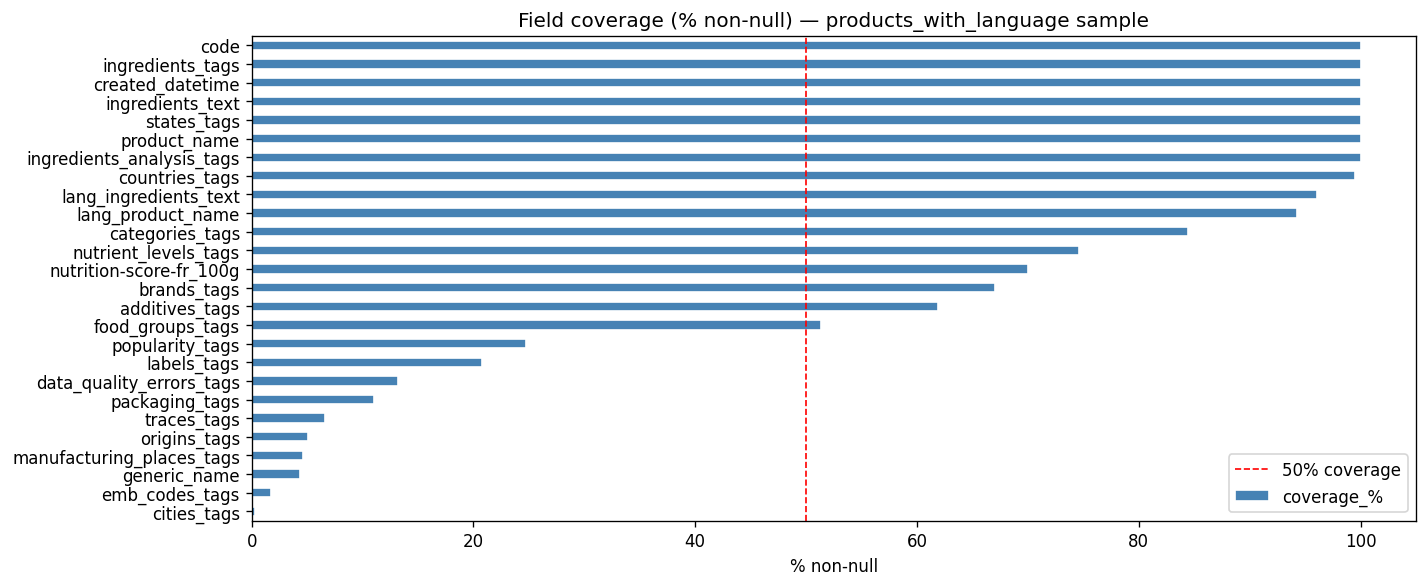

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
coverage['coverage_%'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% coverage')
ax.set_title('Field coverage (% non-null) — products_with_language sample')
ax.set_xlabel('% non-null')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Text Length Analysis (NLP-critical fields)

The three fields relevant for NLP matching are:
- `product_name` — the primary label (used for matching to FoodEx2)
- `generic_name` — a secondary description (often cleaner / more canonical)
- `ingredients_text` — ingredient list (richest semantic content, longest)

In [5]:
text_fields = ['product_name', 'generic_name', 'ingredients_text']

for col in text_fields:
    df[f'{col}_len'] = df[col].str.len()

len_stats = df[[f'{c}_len' for c in text_fields]].describe().round(1)
display(len_stats)

,product_name_len,generic_name_len,ingredients_text_len
count,5299.0,234.0,5300.0
mean,24.6,32.5,277.4
std,12.7,34.9,266.0
min,1.0,4.0,1.0
25%,16.0,14.2,94.0
50%,22.0,22.5,213.0
75%,31.0,39.0,360.2
max,142.0,365.0,2555.0


**Why character length matters:**
1. **Token limits** — Transformer models (BERT, sentence-transformers) cap at 512 tokens (~380 words). Text exceeding this is silently truncated.
2. **Data quality** — Very short `product_name` (< 3 chars) or `ingredients_text` (< 10 chars) signals placeholder or corrupt data.
3. **Embedding information density** — A 5-char product name and a 1,000-char ingredients list yield very different embedding quality.
4. **Field selection strategy** — If `product_name` averages ~30 chars and `ingredients_text` averages ~400 chars, they serve different NLP roles (label vs. context).

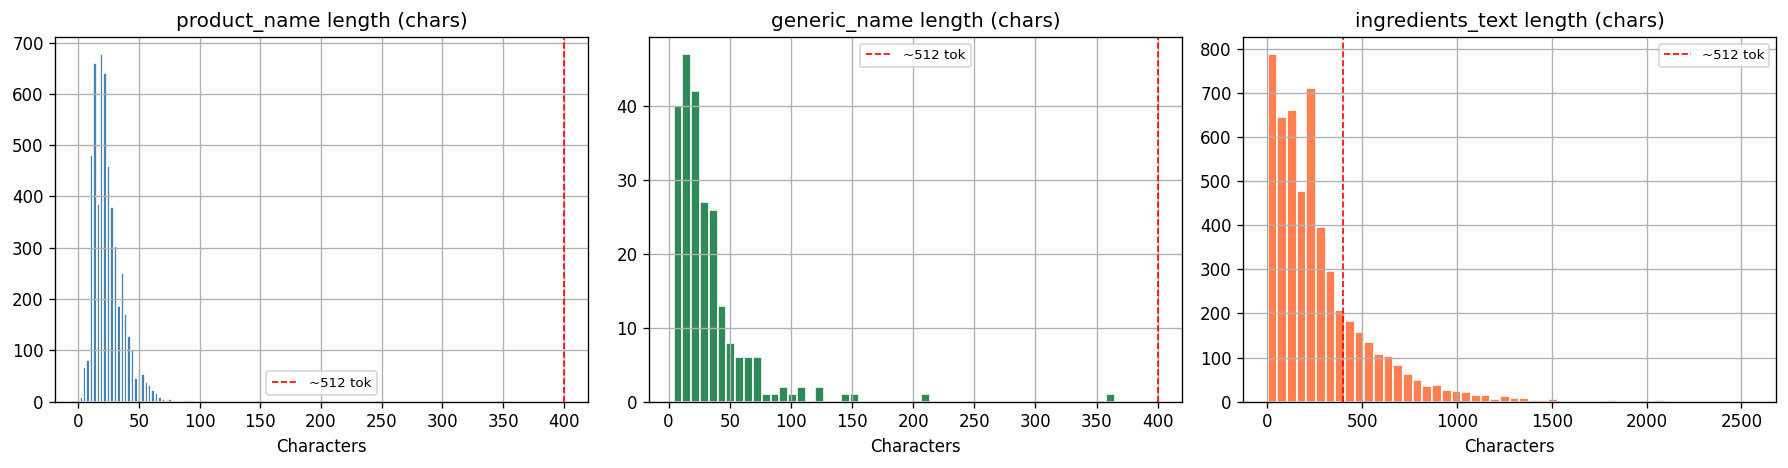

product_name: 0/5299 rows likely exceed 512 tokens (len > 1500 chars)
generic_name: 0/234 rows likely exceed 512 tokens (len > 1500 chars)
ingredients_text: 25/5300 rows likely exceed 512 tokens (len > 1500 chars)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'seagreen', 'coral']

for ax, col, color in zip(axes, text_fields, colors):
    data = df[f'{col}_len'].dropna()
    data.hist(bins=50, ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{col} length (chars)')
    ax.set_xlabel('Characters')
    # Mark 512-token rough limit (~400 chars for 1 token ≈ 0.75 words ≈ 4 chars)
    ax.axvline(400, color='red', linestyle='--', linewidth=1, label='~512 tok')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Token budget check
for col in text_fields:
    over = (df[f'{col}_len'] > 1500).sum()
    total = df[f'{col}_len'].notna().sum()
    print(f'{col}: {over}/{total} rows likely exceed 512 tokens (len > 1500 chars)')

In [7]:
# Products with very short names (potential quality issues)
short_names = df[df['product_name_len'] < 3][['code', 'product_name', 'lang_product_name']]
print(f'Products with product_name < 3 chars: {len(short_names)}')
if len(short_names) > 0:
    display(short_names.head(10))

Products with product_name < 3 chars: 2


,code,product_name,lang_product_name
5122,222222222,qq,NaN
5254,580965886,h,NaN


## 3. Language Distribution & Cross-field Consistency

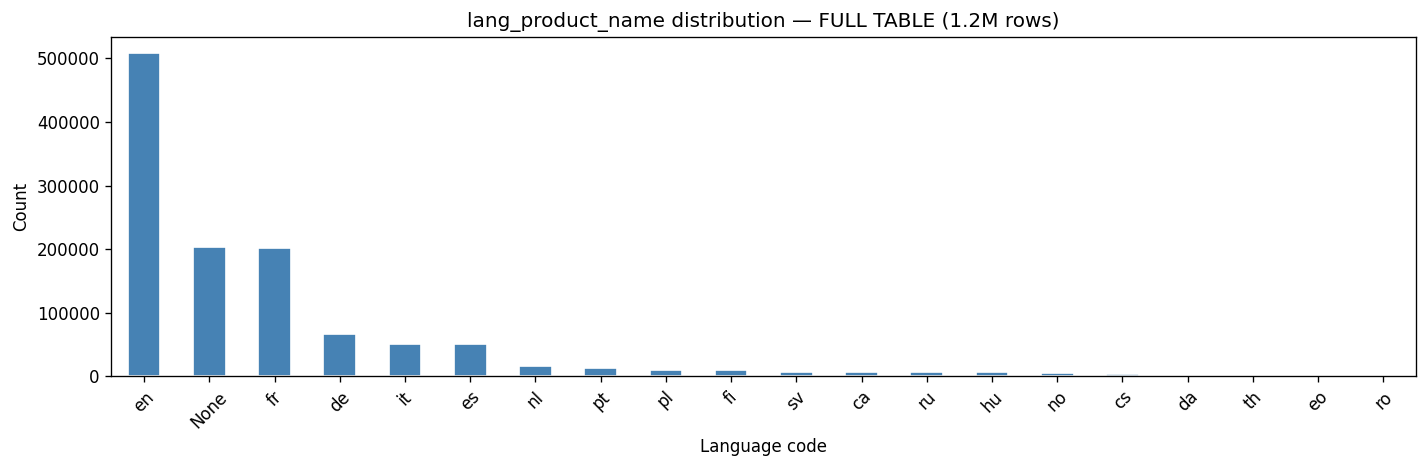

Top languages (full table):
       count
en    508269
None  204125
fr    202503
de     66739
it     51392
es     50250
nl     15577
pt     12854
pl     10299
fi      9559
sv      7284
ca      7281
ru      6835
hu      6116
no      4612
cs      4030
da      2559
th      2167
eo      2121
ro      1888


In [8]:
# Full-table language distribution (from prior query)
full_table_lang = pd.Series({
    'en': 508269, 'None': 204125, 'fr': 202503, 'de': 66739,
    'it': 51392,  'es': 50250,  'nl': 15577, 'pt': 12854,
    'pl': 10299,  'fi': 9559,   'sv': 7284,  'ca': 7281,
    'ru': 6835,   'hu': 6116,   'no': 4612,  'cs': 4030,
    'da': 2559,   'th': 2167,   'eo': 2121,  'ro': 1888
}, name='count')

fig, ax = plt.subplots(figsize=(12, 4))
full_table_lang.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('lang_product_name distribution — FULL TABLE (1.2M rows)')
ax.set_xlabel('Language code')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top languages (full table):')
print(full_table_lang.to_frame())

In [9]:
# Cross-field language consistency in sample
# How often does lang_product_name == lang_ingredients_text?
both = df[df['lang_product_name'].notna() & df['lang_ingredients_text'].notna()]
same_lang = (both['lang_product_name'] == both['lang_ingredients_text']).sum()
print(f'Rows where both lang fields are non-null: {len(both)}')
print(f'  Same language in both fields: {same_lang} ({same_lang/len(both)*100:.1f}%)')
print(f'  Different language:           {len(both)-same_lang} ({(len(both)-same_lang)/len(both)*100:.1f}%)')

# Cases where languages differ — potential multilingual products
diff = both[both['lang_product_name'] != both['lang_ingredients_text']]
print(f'\nLanguage mismatch examples (product_name lang vs ingredients lang):')
display(diff[['code','product_name','lang_product_name','lang_ingredients_text']].head(10))

Rows where both lang fields are non-null: 5000
  Same language in both fields: 835 (16.7%)
  Different language:           4165 (83.3%)

Language mismatch examples (product_name lang vs ingredients lang):


,code,product_name,lang_product_name,lang_ingredients_text
4,33,Vegan Protein 3k Chocolate Flavor,en,de
7,39,Yerba Mate,en,fr
8,42,Multivitamins & Minerals,en,fr
9,50,Thermo complete,en,fr
12,93,Organic Cacao Powder,en,fr
15,127,Whey Protein - Chocolate,en,fr
21,173,BIO CHLORELLA,en,de
22,189,Vegan Protein Mango,en,fr
24,202,VEGAN BRAIN + BODY BOOST,en,zh
31,289,Passiflore BIO,en,fr


**Why language consistency matters:**
- Mismatches mean the product name and ingredient list are in different languages — common for imported products with translated labels.
- For NLP matching to FoodEx2 (which is English-only), rows where `lang_product_name != 'en'` may need translation before embedding.
- The 17% NULL `lang_product_name` rows (204k in full table) will need lang detection before any language-specific processing.
- A model trained only on English products will underperform on French/German/Italian entries — the language split defines your training coverage.

In [10]:
# NULL lang rows: do they have product names?
null_lang = df[df['lang_product_name'].isna()]
print(f'NULL lang_product_name rows in sample: {len(null_lang)}')
print(f'  With non-null product_name: {null_lang["product_name"].notna().sum()} ({null_lang["product_name"].notna().mean()*100:.0f}%)')
print(f'  With non-null ingredients_text: {null_lang["ingredients_text"].notna().sum()} ({null_lang["ingredients_text"].notna().mean()*100:.0f}%)')
print('\nSample NULL-lang product names:')
display(null_lang[['code','product_name','generic_name']].head(10))

NULL lang_product_name rows in sample: 300
  With non-null product_name: 299 (100%)
  With non-null ingredients_text: 300 (100%)

Sample NULL-lang product names:


,code,product_name,generic_name
5000,10,xxx,NaN
5001,16,velvety vanilla cake mix,NaN
5002,29,Anthony's Organic Cocoa Butter Chunks,NaN
5003,34,Graines de Chia,NaN
5004,45,Gummie,NaN
5005,49,Mre Lite,NaN
5006,55,Calcium,NaN
5007,56,juca,NaN
5008,62,Abricots,NaN
5009,73,Whopper,NaN


## 4. Tag Field Analysis

Tag fields (e.g. `categories_tags`, `ingredients_tags`) are comma-separated strings like `en:cereals,en:bread`. They are structured controlled vocabularies — useful as features but need parsing.

In [11]:
tag_cols = [
    'categories_tags', 'ingredients_tags', 'ingredients_analysis_tags',
    'food_groups_tags', 'labels_tags', 'additives_tags',
    'brands_tags', 'countries_tags', 'packaging_tags',
    'traces_tags', 'nutrient_levels_tags', 'data_quality_errors_tags'
]

def count_tags(val):
    if pd.isna(val) or str(val).strip() == '':
        return 0
    return len(str(val).split(','))

tag_stats = pd.DataFrame({
    'coverage_%': [df[c].notna().mean()*100 for c in tag_cols],
    'avg_tags':   [df[c].apply(count_tags).mean() for c in tag_cols],
    'max_tags':   [df[c].apply(count_tags).max() for c in tag_cols],
}, index=tag_cols).round(1)

display(tag_stats.sort_values('coverage_%', ascending=False))

,coverage_%,avg_tags,max_tags
ingredients_tags,100.0,28.5,147
ingredients_analysis_tags,100.0,3.0,3
countries_tags,99.5,1.1,12
categories_tags,84.4,3.1,18
nutrient_levels_tags,74.6,2.8,4
brands_tags,67.0,0.7,4
additives_tags,61.9,2.9,33
food_groups_tags,51.3,1.0,3
labels_tags,20.8,0.5,17
data_quality_errors_tags,13.2,0.3,9


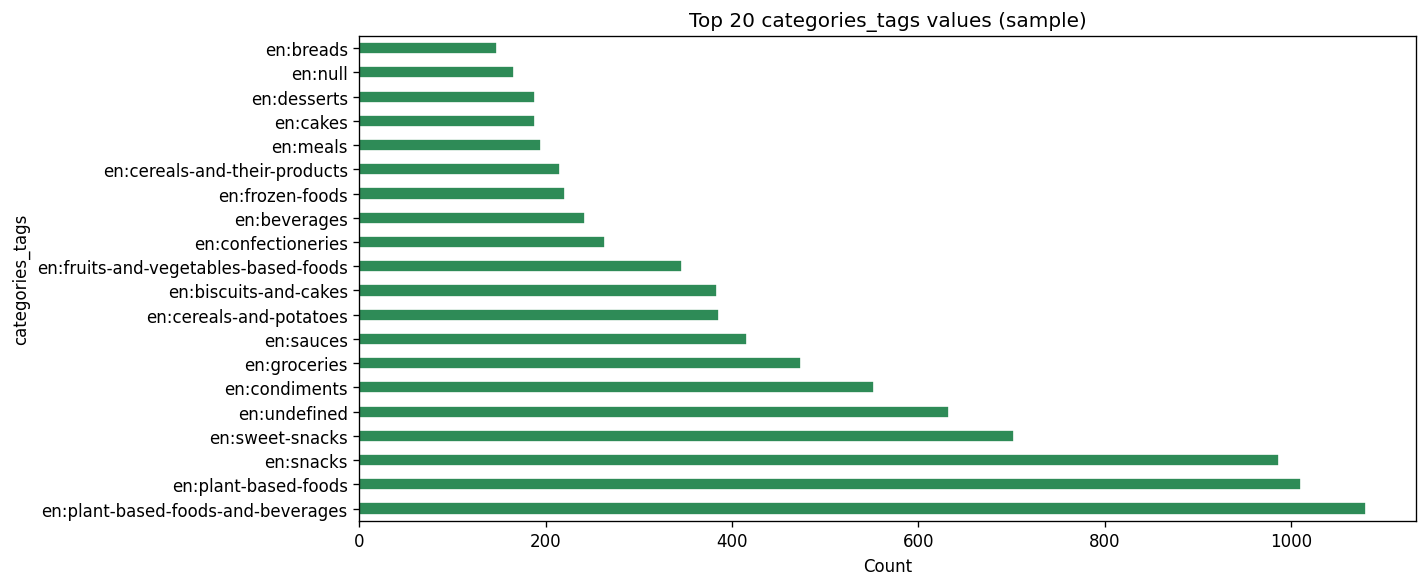

In [12]:
# Most frequent categories
all_cats = (
    df['categories_tags']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
)
top_cats = all_cats.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top_cats.plot(kind='barh', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Top 20 categories_tags values (sample)')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

In [13]:
# Data quality errors by language
dq = df[df['data_quality_errors_tags'].notna()]
print(f'Rows with data quality errors: {len(dq)} ({len(dq)/len(df)*100:.1f}%)')

all_errors = (
    dq['data_quality_errors_tags']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)
print('\nTop data quality error types:')
display(all_errors)

Rows with data quality errors: 699 (13.2%)

Top data quality error types:


data_quality_errors_tags
en:nutrition-value-total-over-105                                             447
en:nutrition-value-over-105-carbohydrates                                     274
en:nutrition-value-over-3800-energy                                           270
en:energy-value-in-kcal-does-not-match-value-computed-from-other-nutrients    243
en:nutrition-value-over-105-sugars                                            148
en:nutrition-value-over-105-fat                                               110
en:energy-value-in-kj-does-not-match-value-computed-from-other-nutrients       22
en:energy-value-in-kcal-does-not-match-value-in-kj                             18
en:nutrition-sugars-plus-starch-greater-than-carbohydrates                     15
en:nutrition-value-over-105-added-sugars                                        8
en:nutrition-value-total-over-1000                                              8
en:nutrition-saturated-fat-greater-than-fat                              

## 5. NLP Data Preparation

### Strategy
For matching products to FoodEx2 terms we build one **rich text string per product**:

```
nlp_text = product_name [. generic_name] [. categories (cleaned)] [. ingredients_text (truncated)]
```

Priority: `product_name` > `generic_name` > `categories` > `ingredients_text`

In [14]:
def clean_text(text, max_chars=None):
    """Lowercase, normalize whitespace, optionally truncate."""
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text).strip()
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    # Remove non-printable characters
    text = re.sub(r'[^\x20-\x7E\xC0-\xFF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if max_chars:
        text = text[:max_chars]
    return text


def parse_tags_to_text(tags_str, lang_prefix='en'):
    """
    Convert a comma-separated tags field to human-readable words.
    Strips language prefix (e.g. 'en:cereals' -> 'cereals').
    Replaces hyphens with spaces.
    """
    if pd.isna(tags_str) or str(tags_str).strip() == '':
        return ''
    tags = [t.strip() for t in str(tags_str).split(',')]
    cleaned = []
    for t in tags:
        # Strip lang prefix (e.g. 'en:', 'fr:')
        t = re.sub(r'^[a-z]{2}:', '', t)
        t = t.replace('-', ' ').replace('_', ' ').strip()
        if t:
            cleaned.append(t)
    return ', '.join(cleaned)


def build_nlp_text(row, ingredients_max_chars=500):
    """
    Build a rich-text NLP string per product.
    
    Fields included (in priority order):
        1. product_name      — always used if present
        2. generic_name      — cleaner canonical label (if present)
        3. categories_tags   — food category hierarchy (cleaned)
        4. food_groups_tags  — broader food group (cleaned)
        5. ingredients_text  — full ingredient list (truncated at ingredients_max_chars)
    """
    parts = []

    name = clean_text(row.get('product_name'))
    if name:
        parts.append(name)

    generic = clean_text(row.get('generic_name'))
    if generic and generic.lower() != name.lower():
        parts.append(generic)

    cats = parse_tags_to_text(row.get('categories_tags'))
    if cats:
        parts.append(cats)

    food_grp = parse_tags_to_text(row.get('food_groups_tags'))
    if food_grp:
        parts.append(food_grp)

    ingredients = clean_text(row.get('ingredients_text'), max_chars=ingredients_max_chars)
    if ingredients:
        parts.append(ingredients)

    # Join with period separator; each part ends with period
    text_parts = []
    for p in parts:
        p = p.rstrip('.')
        if p:
            text_parts.append(p + '.')

    return ' '.join(text_parts)


# Apply cleaning
df['product_name_clean'] = df['product_name'].apply(clean_text)
df['generic_name_clean'] = df['generic_name'].apply(clean_text)
df['ingredients_text_clean'] = df['ingredients_text'].apply(lambda x: clean_text(x, max_chars=500))
df['categories_clean'] = df['categories_tags'].apply(parse_tags_to_text)
df['food_groups_clean'] = df['food_groups_tags'].apply(parse_tags_to_text)

df['nlp_text'] = df.apply(build_nlp_text, axis=1)

print('NLP text length stats:')
print(df['nlp_text'].str.len().describe().round(1))

print('\nSample NLP texts:')
for _, row in df[df['nlp_text'].str.len() > 50].sample(5, random_state=7).iterrows():
    print(f"\n[{row['code']}] lang={row['lang_product_name']}")
    print(row['nlp_text'])

NLP text length stats:
count    5300.0
mean      332.6
std       171.4
min         0.0
25%       202.0
50%       297.0
75%       479.0
max       857.0
Name: nlp_text, dtype: float64

Sample NLP texts:

[15509] lang=pt
Baguette Niçois. sandwiches, cheese sandwiches, goat cheese sandwiches. composite foods, sandwiches. PAIN BAGUETTE 55,4% : Farine de FROMENT, eau, levure, sel. Garniture 44,6% : FROMAGE DE CHEVRE 46,5% (LAIT de chèvre pasteurisé 98,3%, sel 1,5%, ferments LACTIQUES et fongiques, coagulant), tomate 31%, salade verte 20,7%, huile d'olive 1,9%. (% exprimés sur le garniture).

[31919005312] lang=fi
Low Glycemic Cruchy Peanut Butter. undefined. PEANUTS, HYDROGENATED VEGETABLE OIL (RAPESEED, COTTONSEED, SOYBEAN) TO PREVENT SEPARATION.

[1403] lang=fr
Sablés Coco Lait. snacks, sweet snacks, biscuits and cakes, biscuits, chocolate biscuits, shortbread cookies. sugary snacks, biscuits and cakes. Farine de blé 27.5%, chocolat au lait 22% (sucre, beurre de cacao, lait entier en poudr

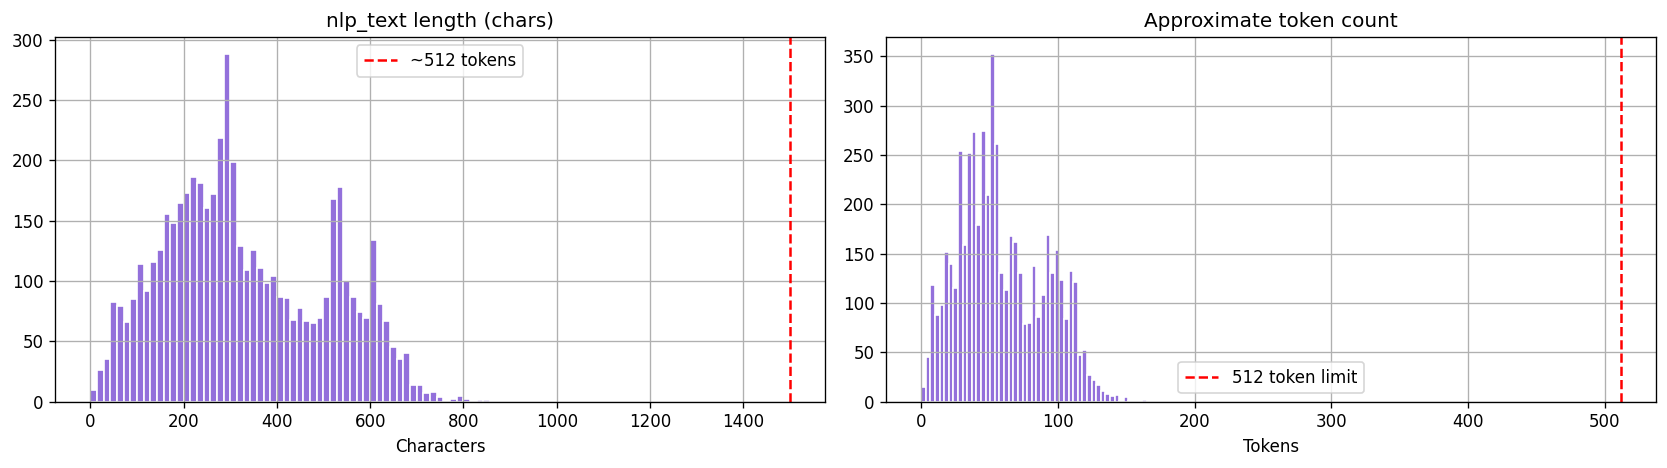

Products likely exceeding 512 tokens: 0/5300 (0.0%)


In [15]:
df['nlp_word_count'] = df['nlp_text'].str.split().str.len()
df['approx_tokens'] = (df['nlp_word_count'] * 1.3).round().astype('Int64')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['nlp_text'].str.len().hist(bins=60, ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].axvline(1500, color='red', linestyle='--', label='~512 tokens')
axes[0].set_title('nlp_text length (chars)')
axes[0].set_xlabel('Characters')
axes[0].legend()

df['approx_tokens'].dropna().astype(int).hist(bins=60, ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].axvline(512, color='red', linestyle='--', label='512 token limit')
axes[1].set_title('Approximate token count')
axes[1].set_xlabel('Tokens')
axes[1].legend()

plt.tight_layout()
plt.show()

over_512 = (df['approx_tokens'].dropna() > 512).sum()
total = df['approx_tokens'].notna().sum()
print(f'Products likely exceeding 512 tokens: {over_512}/{total} ({over_512/total*100:.1f}%)')

In [16]:
# NLP text quality by language
lang_quality = df.groupby('lang_product_name', dropna=False).agg(
    n_products=('code', 'count'),
    pct_has_generic=('generic_name', lambda x: x.notna().mean() * 100),
    pct_has_ingredients=('ingredients_text', lambda x: x.notna().mean() * 100),
    pct_has_categories=('categories_tags', lambda x: x.notna().mean() * 100),
    avg_nlp_len=('nlp_text', lambda x: x.str.len().mean()),
).round(1).sort_values('n_products', ascending=False)

print('NLP field coverage by language:')
display(lang_quality)

NLP field coverage by language:


,n_products,pct_has_generic,pct_has_ingredients,pct_has_categories,avg_nlp_len
lang_product_name,,,,,
de,500,4.4,100.0,86.0,331.3
en,500,5.2,100.0,68.8,316.6
es,500,7.2,100.0,85.4,345.8
fi,500,2.0,100.0,87.2,306.6
fr,500,12.0,100.0,84.0,367.5
it,500,4.4,100.0,84.8,337.2
nl,500,2.0,100.0,87.8,330.8
pl,500,3.2,100.0,87.6,408.7
pt,500,1.6,100.0,89.8,327.2


In [17]:
# Products with empty nlp_text (nothing to match on)
empty_nlp = df[df['nlp_text'].str.strip() == '']
print(f'Products with empty nlp_text: {len(empty_nlp)} ({len(empty_nlp)/len(df)*100:.1f}%)')
if len(empty_nlp) > 0:
    display(empty_nlp[['code','product_name','generic_name','ingredients_text']].head(5))

Products with empty nlp_text: 1 (0.0%)


,code,product_name,generic_name,ingredients_text
5285,7301,Нейм,NaN,Моят диск Споделени с мен


## 6. Export NLP-ready Dataset

In [18]:
nlp_df = df[[
    'code',
    'lang_product_name',
    'lang_ingredients_text',
    'product_name_clean',
    'generic_name_clean',
    'categories_clean',
    'food_groups_clean',
    'ingredients_text_clean',
    'nlp_text',
    'nlp_word_count',
    'approx_tokens',
    'nutrition-score-fr_100g',
    'created_datetime',
]].copy()

print(f'Final NLP-ready dataset shape: {nlp_df.shape}')
display(nlp_df.head(3))

nlp_df.to_csv('products_nlp.csv', index=False)
print('\nSaved to products_nlp.csv')

Final NLP-ready dataset shape: (5300, 13)


,code,lang_product_name,lang_ingredients_text,product_name_clean,generic_name_clean,categories_clean,food_groups_clean,ingredients_text_clean,nlp_text,nlp_word_count,approx_tokens,nutrition-score-fr_100g,created_datetime
0,13,en,en,Powdered peanut butter,,"snacks, meals, rice dishes, risottos, powder peanut butter","composite foods, one dish meals","Water, Leptospermum Scoparium Mel (Manuka Honey), Sodium C14-C16 Olefin Sulfonate, Cocamide DIPA , Cocamidopropyl Be...","Powdered peanut butter. snacks, meals, rice dishes, risottos, powder peanut butter. composite foods, one dish meals....",54,70,3.0,2019-03-30 19:25:19+01:00
1,17,en,en,Collagen For Her,,,,"whey protein concentrate, milk protein concentrate, flavoring, thickener (xanthan gum), sweetener (sucralose)","Collagen For Her. whey protein concentrate, milk protein concentrate, flavoring, thickener (xanthan gum), sweetener ...",15,20,NaN,2024-10-12 14:40:11+02:00
2,25,en,en,Frog Fuel Power Protein,,protein,,"glucose syrup, sugar, water, pectin, black carrot concentrate and chlorophyll (color), citric acid, trisodium citrat...","Frog Fuel Power Protein. protein. glucose syrup, sugar, water, pectin, black carrot concentrate and chlorophyll (col...",22,29,NaN,2023-01-10 07:23:08+01:00



Saved to products_nlp.csv


In [19]:
print('=== EDA SUMMARY ===')
print(f'Full table size:         1,206,996 rows × 26 columns')
print(f'Sample used:             {len(df):,} rows (stratified by lang_product_name)')
print()
print('Language split (full table):')
print('  English (en):          42.1%')
print('  French  (fr):          16.8%')
print('  No lang detected:      16.9%')
print('  German/Italian/Spanish: ~14%')
print('  Other languages:        ~10%')
print()
print('NLP-critical field coverage (sample):')
for col in ['product_name', 'generic_name', 'ingredients_text', 'categories_tags', 'food_groups_tags']:
    pct = df[col].notna().mean() * 100
    print(f'  {col:<30} {pct:.1f}%')
print()
print('Key NLP considerations:')
print('  - ~17% rows have NULL lang → need language detection before lang-specific processing')
print('  - ingredients_text is the richest field but longest — truncate at ~500 chars for transformers')
print('  - categories_tags hierarchy can substitute missing product_name context')
print('  - Multilingual products (lang mismatch between name/ingredients) need special handling')
print('  - data_quality_errors_tags flags rows to consider filtering from training')

=== EDA SUMMARY ===
Full table size:         1,206,996 rows × 26 columns
Sample used:             5,300 rows (stratified by lang_product_name)

Language split (full table):
  English (en):          42.1%
  French  (fr):          16.8%
  No lang detected:      16.9%
  German/Italian/Spanish: ~14%
  Other languages:        ~10%

NLP-critical field coverage (sample):
  product_name                   100.0%
  generic_name                   4.4%
  ingredients_text               100.0%
  categories_tags                84.4%
  food_groups_tags               51.3%

Key NLP considerations:
  - ~17% rows have NULL lang → need language detection before lang-specific processing
  - ingredients_text is the richest field but longest — truncate at ~500 chars for transformers
  - categories_tags hierarchy can substitute missing product_name context
  - Multilingual products (lang mismatch between name/ingredients) need special handling
  - data_quality_errors_tags flags rows to consider filtering from